In [28]:
import kagglehub
import os
import torch
import torchvision
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

print("Downloading dataset from Kaggle...")
dataset_path = kagglehub.dataset_download("xhlulu/140k-real-and-fake-faces")
print(f"Dataset downloaded to: {dataset_path}")

Dataset downloaded to: C:\Users\harsh\.cache\kagglehub\datasets\xhlulu\140k-real-and-fake-faces\versions\2


In [29]:
print(f"Dataset downloaded to: {dataset_path}")

data_dir = os.path.join(dataset_path, 'real_vs_fake', 'real-vs-fake')
print(f"Root data directory contains: {os.listdir(data_dir)}")
classes = os.listdir(os.path.join(data_dir, 'train'))
print(f"Training classes found: {classes}")

Dataset downloaded to: C:\Users\harsh\.cache\kagglehub\datasets\xhlulu\140k-real-and-fake-faces\versions\2
Root data directory contains: ['test', 'train', 'valid']
Training classes found: ['fake', 'real']


In [30]:
data_dir

'C:\\Users\\harsh\\.cache\\kagglehub\\datasets\\xhlulu\\140k-real-and-fake-faces\\versions\\2\\real_vs_fake\\real-vs-fake'

In [31]:
classes

['fake', 'real']

In [32]:
from torchvision.datasets import ImageFolder
import torchvision.transforms as tt

train_tfms = tt.Compose([
                         tt.ToTensor(),
                         tt.Resize((64,64), antialias=True)
                        ])
valid_tfms = tt.Compose([tt.ToTensor(),
                        tt.Resize((64,64), antialias=True)])

In [33]:
train_ds = ImageFolder(data_dir+'/train', train_tfms)
valid_ds = ImageFolder(data_dir+'/test', valid_tfms)

print(f"No. of training examples: {len(train_ds)}")
print(f"No. of validation examples: {len(valid_ds)}")

No. of training examples: 100000
No. of validation examples: 20000


In [34]:


from torch.utils.data import DataLoader

batch_size = 32

train_dl = DataLoader(train_ds, batch_size, shuffle=True, num_workers=0, pin_memory=False)
valid_dl = DataLoader(valid_ds, batch_size*2, num_workers=0, pin_memory=False)

for images, labels in train_dl:
    print(f"Images batch shape: {images.shape}")
    print(f"Labels batch shape: {labels.shape}")
    break

Images batch shape: torch.Size([32, 3, 64, 64])
Labels batch shape: torch.Size([32])


In [35]:
import time
t0 = time.time()
images, labels = next(iter(train_dl))
print(f"Time: {time.time()-t0:.2f}s")

Time: 0.21s


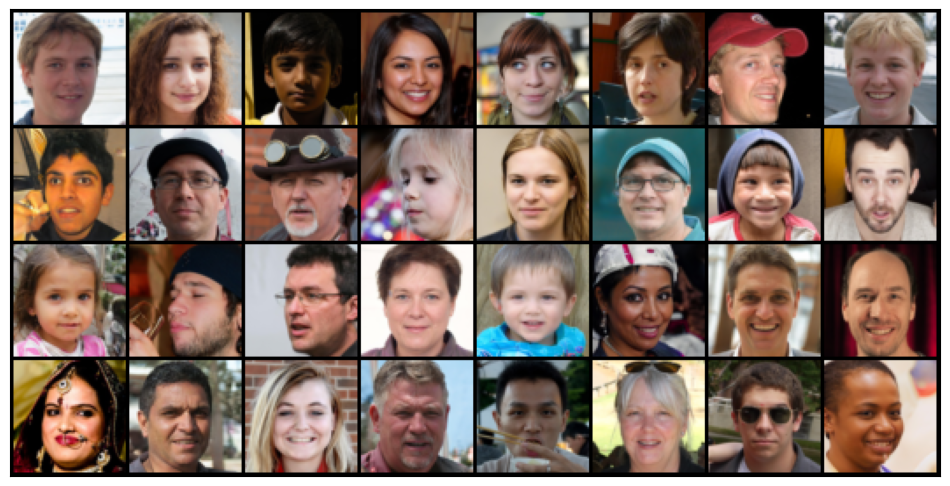

In [36]:
from torchvision.utils import make_grid

def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(12, 12))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(images[:64], nrow=8).permute(1, 2, 0).clamp(0,1))
        break

show_batch(train_dl)

In [37]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [38]:
def to_device(data):
    if isinstance(data, (list, tuple)):
        return [x.to(device, non_blocking=True) for x in data]
    return data.to(device, non_blocking=True)


class DeviceLoader:
    def __init__(self, dl):
        self.dl = dl
    def __iter__(self):
        for batch in self.dl:
            yield to_device(batch)
    def __len__(self):
        return len(self.dl)


train_dl = DeviceLoader(train_dl)
valid_dl = DeviceLoader(valid_dl)

In [39]:
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def metrics(outputs, labels):
   
    preds = (outputs >= 0.5).float().cpu().detach().numpy()
    labels = labels.cpu().detach().numpy()

    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)

    return {
        'accuracy': torch.tensor(accuracy, device=outputs.device),
        'precision': torch.tensor(precision, device=outputs.device),
        'recall': torch.tensor(recall, device=outputs.device),
        'f1_score': torch.tensor(f1, device=outputs.device)
    }

class ImageClassificationBase(nn.Module):

    def training_step(self, batch):
        images, labels = batch
        labels = labels.unsqueeze(1).float() 
        out = self(images)                  
        loss = F.binary_cross_entropy(out, labels) 
        return loss

    def validation_step(self, batch):
        images, labels = batch
        labels = labels.unsqueeze(1).float()
        out = self(images)                    
        loss = F.binary_cross_entropy(out, labels)   

        return {
            'val_loss': loss.detach(),
            'outputs': out.detach().cpu(), 
            'labels': labels.detach().cpu()
        }

    def validation_epoch_end(self, outputs):
        
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()

        all_outputs = torch.cat([x['outputs'] for x in outputs], dim=0)
        all_labels = torch.cat([x['labels'] for x in outputs], dim=0)

        metric_values = metrics(all_outputs, all_labels)

        return {
            'val_loss': epoch_loss.item(),
            'val_acc': metric_values['accuracy'].item(),
            'val_precision': metric_values['precision'].item(),
            'val_recall': metric_values['recall'].item(),
            'val_f1': metric_values['f1_score'].item()
        }

    def epoch_end(self, epoch, result):
        
        print("Epoch [{}], last_lr: {:.4f}, train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}, val_prec: {:.4f}, val_rec: {:.4f}, val_f1: {:.4f}".format(
            epoch, result['lrs'][-1], result['train_loss'], result['val_loss'],
            result['val_acc'], result['val_precision'], result['val_recall'], result['val_f1']))

In [40]:
class CNNModel(ImageClassificationBase):
    def __init__(self):
        super(CNNModel, self).__init__()

       
        self.conv1 = nn.Conv2d(3, 8, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(8)

        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(16, 16, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(16)
        self.pool1 = nn.AvgPool2d(2, 2)

        self.conv4 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(32)
        self.pool2 = nn.AvgPool2d(2, 2)

        self.conv6 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv7 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv8 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv9 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.pool3 = nn.AvgPool2d(2, 2)

        self.conv10 = nn.Conv2d(64, 128, kernel_size=5, padding=2)
        self.bn5 = nn.BatchNorm2d(128)
        self.pool4 = nn.MaxPool2d(2, 2)

        self.conv11 = nn.Conv2d(128, 256, kernel_size=5, padding=2)
        self.bn6 = nn.BatchNorm2d(256)
        self.pool5 = nn.MaxPool2d(2, 2)

        
        self.fc1 = nn.Linear(256, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)

     
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
      
        x = self.pool1(F.leaky_relu(self.bn1(self.conv1(x))))
        x = self.pool1(F.leaky_relu(self.bn2(self.conv3(F.leaky_relu(self.conv2(x))))))
        x = self.pool2(F.leaky_relu(self.bn3(self.conv5(F.leaky_relu(self.conv4(x))))))
        x = self.pool3(F.leaky_relu(self.bn4(self.conv9(F.leaky_relu(self.conv8(F.leaky_relu(self.conv7(F.leaky_relu(self.conv6(x))))))))))
        x = self.pool4(F.leaky_relu(self.bn5(self.conv10(x))))
        x = self.pool5(F.leaky_relu(self.bn6(self.conv11(x))))

       
        x = torch.flatten(x, 1)
        x = self.dropout(F.leaky_relu(self.fc1(x)))
        x = self.dropout(F.leaky_relu(self.fc2(x)))
        x = self.fc3(x)

        
        return torch.sigmoid(x)

In [41]:
model = to_device(CNNModel())
model

CNNModel(
  (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv5): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv8): Conv2d(64, 64, kernel_size=(3,

In [42]:
from tqdm import tqdm

CHECKPOINT_PATH = "model_checkpoint_deepcnn.pth"

@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def get_lr(optimizer):
    return optimizer.param_groups[0]['lr']

def save_checkpoint(epoch, model, optimizer, scheduler, history):
    """Save model checkpoint locally."""
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),  # Save scheduler
        'history': history
    }, CHECKPOINT_PATH)
    print(f"Checkpoint saved at epoch {epoch+1}")


def load_checkpoint(model, optimizer, scheduler):
    """Load model checkpoint if available."""
    if os.path.exists(CHECKPOINT_PATH):
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])  # Load scheduler
        history = checkpoint['history']
        start_epoch = checkpoint['epoch'] + 1

     
        for param_group in optimizer.param_groups:
            param_group['lr'] = get_lr(optimizer)

        print(f"Resuming training from epoch {start_epoch}, with LR: {get_lr(optimizer)}")
        return start_epoch, history
    return 0, []

def fit_one_cycle(epochs, max_lr, model, train_loader, val_loader,
                  weight_decay=0, grad_clip=None, opt_func=torch.optim.Adam):
    torch.cuda.empty_cache()

    optimizer = opt_func(model.parameters(), lr=max_lr, weight_decay=weight_decay)


    sched = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epochs,
                                                steps_per_epoch=len(train_loader))


    start_epoch, history = load_checkpoint(model, optimizer, sched)

    for epoch in range(start_epoch, epochs):  # Start from last saved epoch
        model.train()
        train_losses = []
        lrs = []

        with tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", unit="batch") as pbar:
            for batch in pbar:
                loss = model.training_step(batch)
                train_losses.append(loss)
                loss.backward()

                if grad_clip:
                    nn.utils.clip_grad_value_(model.parameters(), grad_clip)

                optimizer.step()
                sched.step()  # Move AFTER optimizer step
                optimizer.zero_grad()

                lrs.append(get_lr(optimizer))
                pbar.set_postfix(loss=loss.item(), lr=lrs[-1])


        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        result['lrs'] = lrs
        model.epoch_end(epoch, result)
        history.append(result)


        save_checkpoint(epoch, model, optimizer, sched, history)

    return history

In [43]:
history = [evaluate(model, valid_dl)]
history

[{'val_loss': 0.6941152811050415,
  'val_acc': 0.5,
  'val_precision': 0.0,
  'val_recall': 0.0,
  'val_f1': 0.0}]

In [44]:
epochs = 11
max_lr = 0.005
grad_clip = 0.1
weight_decay = 1e-4
opt_func = torch.optim.AdamW

In [45]:
%%time
history += fit_one_cycle(epochs, max_lr, model, train_dl, valid_dl,
                             grad_clip=grad_clip,
                             weight_decay=weight_decay,
                             opt_func=opt_func)

Resuming training from epoch 11, with LR: 2.0021307207090248e-08
CPU times: total: 828 ms
Wall time: 145 ms


In [46]:
torch.save(model.state_dict(), "checkpoint.pth")

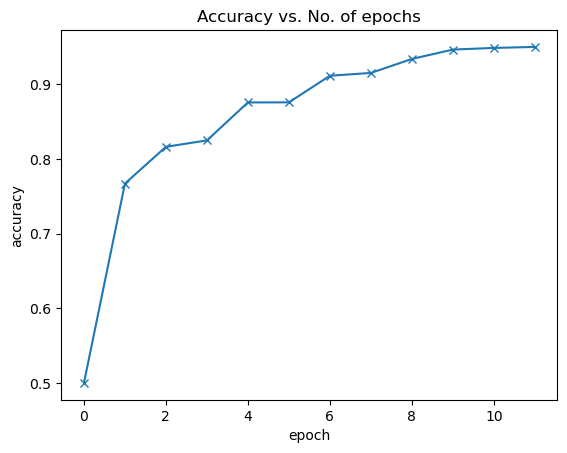

In [47]:
def plot_accuracies(history):
    accuracies = [x['val_acc'] for x in history]
    plt.plot(accuracies, '-x')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Accuracy vs. No. of epochs');

plot_accuracies(history)

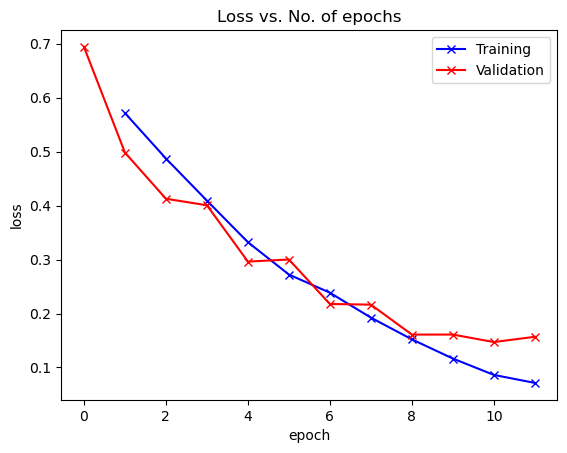

In [48]:
def plot_losses(history):
    train_losses = [x.get('train_loss') for x in history]
    val_losses = [x['val_loss'] for x in history]
    plt.plot(train_losses, '-bx')
    plt.plot(val_losses, '-rx')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend(['Training', 'Validation'])
    plt.title('Loss vs. No. of epochs');

plot_losses(history)

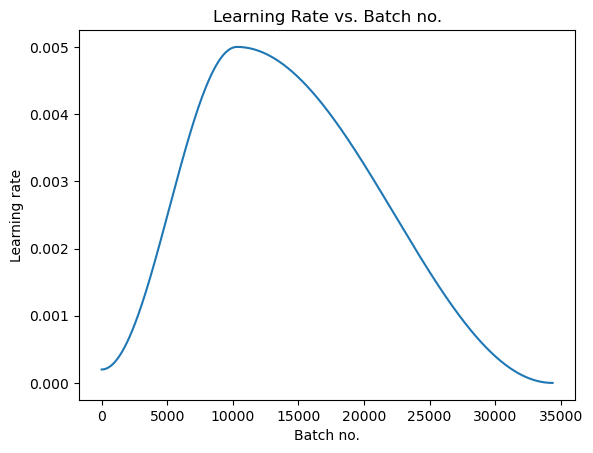

In [49]:
def plot_lrs(history):
    lrs = np.concatenate([x.get('lrs', []) for x in history])
    plt.plot(lrs)
    plt.xlabel('Batch no.')
    plt.ylabel('Learning rate')
    plt.title('Learning Rate vs. Batch no.');

plot_lrs(history)

Label: fake , Predicted: fake


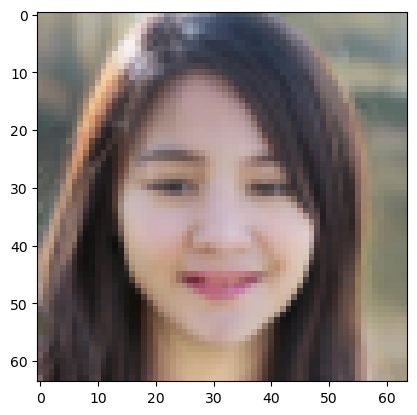

In [50]:
## 32,3,64,64  1,3,64,64
def predict_image(img, model):
    # Convert to a batch of 1
    xb = to_device(img.unsqueeze(0))
    # Get predictions from model
    yb = model(xb)
    # Get the predicted class (0 for fake, 1 for real)
    pred = (yb >= 0.5).float().item()
    # Retrieve the class label
    return train_ds.classes[int(pred)]

# Test on a 'fake' image
img, label = valid_ds[0]
plt.imshow(img.permute(1, 2, 0).clamp(0, 1))
print('Label:', train_ds.classes[label], ', Predicted:', predict_image(img, model))


Label: real , Predicted: real


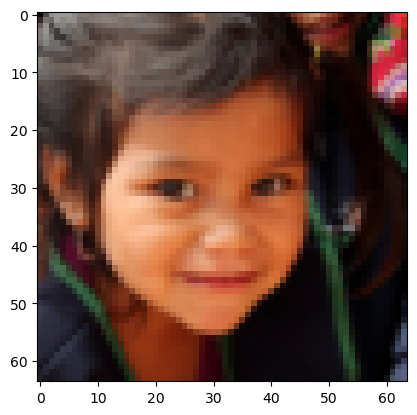

In [51]:
# Test on a 'real' image
img, label = valid_ds[10002]
plt.imshow(img.permute(1, 2, 0).clamp(0, 1))
print('Label:', valid_ds.classes[label], ', Predicted:', predict_image(img, model))

Label: fake , Predicted: fake


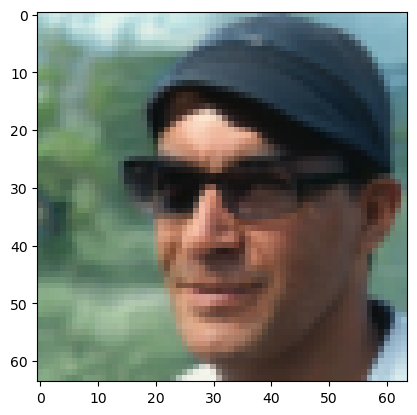

In [52]:
img, label = valid_ds[102]
plt.imshow(img.permute(1, 2, 0).clamp(0, 1))
print('Label:', valid_ds.classes[label], ', Predicted:', predict_image(img, model))

Label: real , Predicted: real


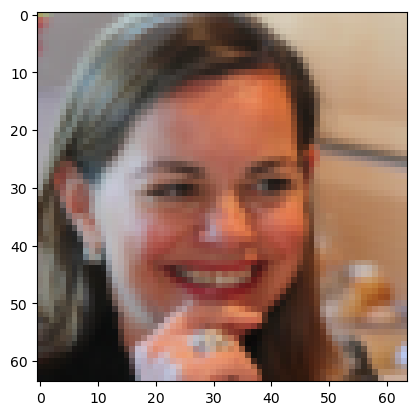

In [54]:
img, label = valid_ds[10211]
plt.imshow(img.permute(1, 2, 0).clamp(0, 1))
print('Label:', valid_ds.classes[label], ', Predicted:', predict_image(img, model))

Label: fake , Predicted: fake


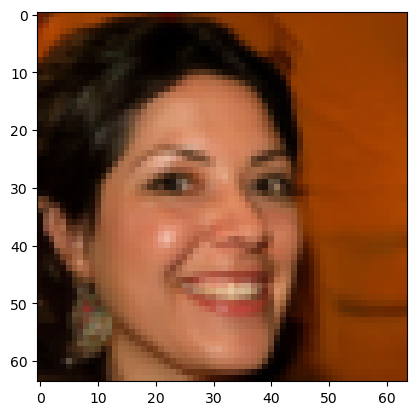

In [55]:
img, label = valid_ds[1021]
plt.imshow(img.permute(1, 2, 0).clamp(0, 1))
print('Label:', valid_ds.classes[label], ', Predicted:', predict_image(img, model))

Label: real , Predicted: real


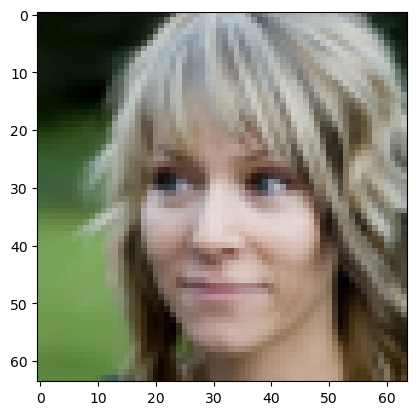

In [56]:
img, label = valid_ds[10223]
plt.imshow(img.permute(1, 2, 0).clamp(0, 1))
print('Label:', valid_ds.classes[label], ', Predicted:', predict_image(img, model))

Label: fake , Predicted: fake


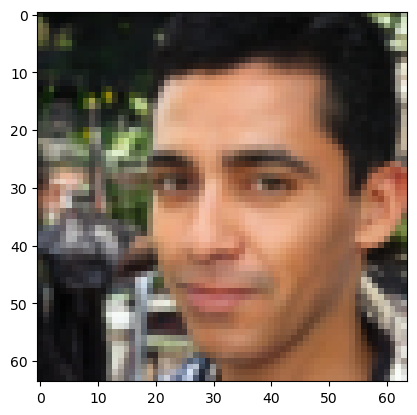

In [57]:
img, label = valid_ds[1023]
plt.imshow(img.permute(1, 2, 0).clamp(0, 1))
print('Label:', valid_ds.classes[label], ', Predicted:', predict_image(img, model))